## Lab 4c
#### MNIST Classification using Scikit-Learn MLPClassifier
<img src="https://raw.githubusercontent.com/wooihaw/ml_dl_comparison/main/ml_mnist.jpg" width="800" height="300">

In [1]:
# Initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler

In [3]:
# ------------------------------------------------------------
# Load the MNIST dataset (from Keras)
# ------------------------------------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten 28x28 images into 784-dimensional vectors
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------
# To do: Use StandardScaler for feature scaling
scl = StandardScaler()
Xs_train = scl.fit_transform(X_train)
Xs_test = scl.transform(X_test)

In [6]:
# ------------------------------------------------------------
# Build the MLPClassifier model
# ------------------------------------------------------------
# To do: build and train MLPClassifier with two hidden layers of 128 and 64 neurons, respectively
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), verbose=True, max_iter=30, random_state=42).fit(Xs_train, y_train)

Iteration 1, loss = 0.32137156
Iteration 2, loss = 0.11324303
Iteration 3, loss = 0.07211136
Iteration 4, loss = 0.05004416
Iteration 5, loss = 0.03622243
Iteration 6, loss = 0.02601377
Iteration 7, loss = 0.01932850
Iteration 8, loss = 0.01586592
Iteration 9, loss = 0.01463713
Iteration 10, loss = 0.01196007
Iteration 11, loss = 0.00915400
Iteration 12, loss = 0.01042801
Iteration 13, loss = 0.01252590
Iteration 14, loss = 0.01170697
Iteration 15, loss = 0.01546533
Iteration 16, loss = 0.01558346
Iteration 17, loss = 0.01029198
Iteration 18, loss = 0.00713142
Iteration 19, loss = 0.00416813
Iteration 20, loss = 0.00343242
Iteration 21, loss = 0.01005911
Iteration 22, loss = 0.01222345
Iteration 23, loss = 0.01031705
Iteration 24, loss = 0.00563214
Iteration 25, loss = 0.00419714
Iteration 26, loss = 0.00595979
Iteration 27, loss = 0.00850086
Iteration 28, loss = 0.00448184
Iteration 29, loss = 0.00625711
Iteration 30, loss = 0.00317751


In [7]:
# ------------------------------------------------------------
# Evaluate the model
# ------------------------------------------------------------
# To do:
# i. Evaluate the overall acuuracy using the scaled testing set
# ii. Print the classification report
print(f'MLP accuracy: {mlp.score(Xs_test, y_test):.3%}')

y_pred = mlp.predict(Xs_test)
print(classification_report(y_test, y_pred))

MLP accuracy: 97.580%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



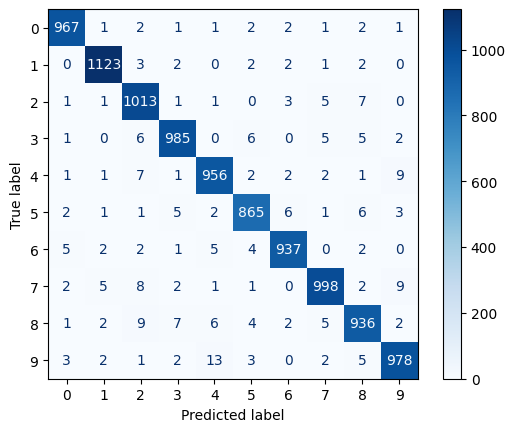

In [8]:
# ------------------------------------------------------------
# Confusion Matrix for MLPClassifier
# ------------------------------------------------------------
# To do: Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')